In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import fft, fftfreq, next_fast_len
from obspy.core import read, Trace
from obspy.core import Stream
from glob import glob
from obspy.signal import PPSD
from pathlib import Path
import obspy

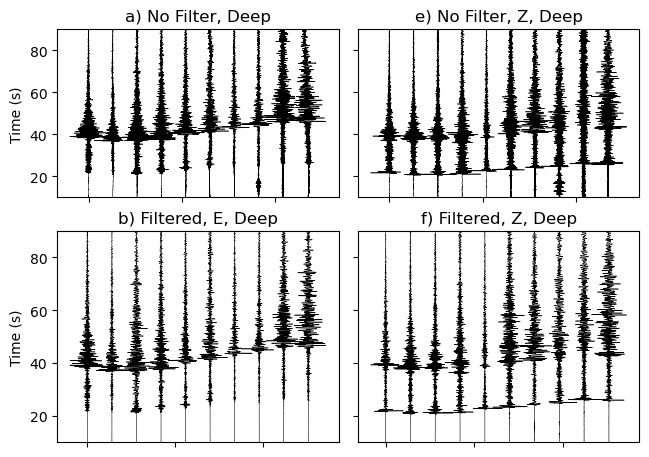

In [54]:
# Arrivals and spectrum for a local deep earthquake on Alaska BADGER stations
# Event: 7/09/23, 20:57:48 UTC
from obspy.signal import filter
import obspy
import matplotlib.ticker as mticker

Ev= '2023.190.20.00.00'
EvDir= '2023.190'
sta= ['BA01','BA05','BA110','BA04','BA03','BA02','BA08','BA07','BA06','BA10'] # No BA05 during this event.
sta_names= ['KNOB','ANCH','HAPP','NNIL','CLAM','COHO','KENA','SOLD','STER','NSKI']
start_time= obspy.UTCDateTime("2023-07-09T20:57:48.000Z")

fig2= plt.figure()
ax1= fig2.add_axes([0.1, 0.55, 0.44, 0.35])
ax2= fig2.add_axes([0.1, 0.04, 0.44, 0.44])
ax3= fig2.add_axes([0.57, 0.55, 0.44, 0.35])
ax4= fig2.add_axes([0.57, 0.04, 0.44, 0.44])

# Plot all traces
BB_traces1=[]; BB_traces2=[]
for i in range(0,len(sta)):
    fnameE= '/Volumes/golos/SAC-S2/'+EvDir+'/XX.'+sta[i]+'.'+Ev+'.HHE.SAC'
    tr= read(fnameE, format='SAC',starttime=start_time,endtime=start_time+100)
    tr_orig= tr[0].copy()
    tr_filt= tr_orig.copy(); tr2_filt= tr_orig.copy()
    f= tr[0].stats.sampling_rate
    npts= tr[0].stats.npts
    BB_time= np.linspace(0,npts/f,npts)
    tr_orig.detrend('demean')
    tr_orig.normalize()
    fnameZ= '/Volumes/golos/SAC-S2/'+EvDir+'/XX.'+sta[i]+'.'+Ev+'.HHZ.SAC'
    trZ= read(fnameZ, format='SAC',starttime=start_time,endtime=start_time+100)
    trZ_orig= trZ[0].copy()
    trZ_filt= trZ_orig.copy(); tr2Z_filt= trZ_orig.copy()
    trZ_orig.detrend('demean')
    trZ_orig.normalize()
    ax1.plot(tr_orig.data+i*1.3,BB_time,linewidth=0.4,color='black')
    ax3.plot(trZ_orig.data+i*1.3,BB_time,linewidth=0.4,color='black')
    # Filtered traces
    tr_filt.detrend('demean')
    tr_filt= tr_filt.filter("bandpass",freqmin=1.0,freqmax=5.0,corners=4,zerophase=False)
    tr_filt.normalize()
    trZ_filt.detrend('demean')
    trZ_filt= trZ_filt.filter("bandpass",freqmin=1.0,freqmax=5.0,corners=4,zerophase=False)
    trZ_filt.normalize()
    ax2.plot(tr_filt.data+i*1.4,BB_time,linewidth=0.4,color='black')
    ax4.plot(trZ_filt.data+i*1.4,BB_time,linewidth=0.4,color='black')
    del tr; del tr_filt; del tr_orig
    


ax1.set_ylabel('Time (s)')
ax1.set_xticklabels([])
ax1.set_ylim(10,90)
ax1.set_title('a) No Filter, Deep')


ax2.set_ylabel('Time (s)')
ax2.set_xticklabels([])
ax2.set_ylim(10,90)
ax2.set_title('b) Filtered, E, Deep')


ax3.set_yticklabels([])
ax3.set_xticklabels([])
ax3.set_ylim(10,90)
ax3.set_title('e) No Filter, Z, Deep')

ax4.set_yticklabels([])
ax4.set_xticklabels([])
ax4.set_ylim(10,90)
ax4.set_title('f) Filtered, Z, Deep')

plt.show()

fig2.savefig('Figures_data/BADGER_Deep.png',dpi=200,bbox_inches='tight')

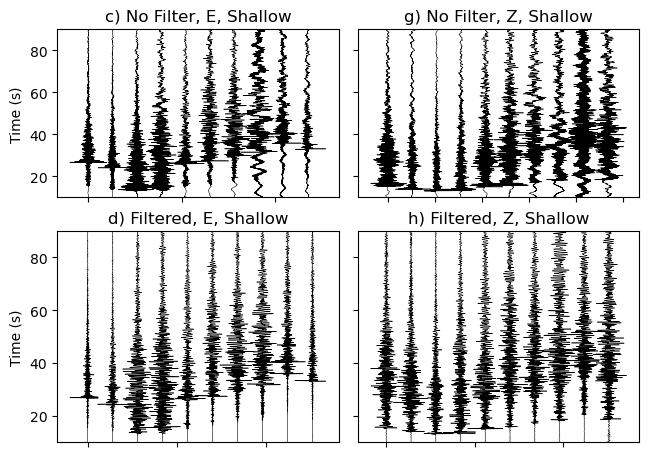

In [55]:
# Arrivals and spectrum for a local shallow earthquake on Alaska BADGER stations
# Event: 7/09/23, 20:57:48 UTC
from obspy.signal import filter
import obspy
import matplotlib.ticker as mticker

Ev= '2023.261.06.00.00'
EvDir= '2023.261'
sta= ['BA01','BA05','BA110','BA04','BA03','BA02','BA08','BA07','BA06','BA10'] # No BA05 during this event.
sta_names= ['KNOB','ANCH','HAPP','NNIL','CLAM','COHO','KENA','SOLD','STER','NSKI']
start_time= obspy.UTCDateTime("2023-09-18T06:09:43.000Z")

fmin= 1.0; fmax= 5.0

fig2= plt.figure()
ax1= fig2.add_axes([0.1, 0.55, 0.44, 0.35])
ax2= fig2.add_axes([0.1, 0.04, 0.44, 0.44])
ax3= fig2.add_axes([0.57, 0.55, 0.44, 0.35])
ax4= fig2.add_axes([0.57, 0.04, 0.44, 0.44])

BB_traces1=[]; BB_traces2=[]
for i in range(0,len(sta)): #range(0,len(sta)):
    fnameE= '/Volumes/golos/SAC-S2/'+EvDir+'/XX.'+sta[i]+'.'+Ev+'.HHE.SAC'
    tr= read(fnameE, format='SAC',starttime=start_time,endtime=start_time+100)
    tr_orig= tr[0].copy()
    tr_filt= tr_orig.copy(); tr2_filt= tr_orig.copy()
    f= tr[0].stats.sampling_rate
    npts= tr[0].stats.npts
    BB_time= np.linspace(0,npts/f,npts)
    tr_orig.detrend('demean')
    tr_orig.normalize()
    fnameZ= '/Volumes/golos/SAC-S2/'+EvDir+'/XX.'+sta[i]+'.'+Ev+'.HHZ.SAC'
    trZ= read(fnameZ, format='SAC',starttime=start_time,endtime=start_time+100)
    trZ_orig= trZ[0].copy()
    trZ_filt= trZ_orig.copy(); tr2Z_filt= trZ_orig.copy()
    trZ_orig.detrend('demean')
    trZ_orig.normalize()
    ax1.plot(tr_orig.data+i*1.3,BB_time,linewidth=0.4,color='black')
    ax3.plot(trZ_orig.data+i*1.3,BB_time,linewidth=0.4,color='black')
    # Filtered
    tr_filt.detrend('demean')
    tr_filt= tr_filt.filter("bandpass",freqmin=fmin,freqmax=fmax,corners=4,zerophase=False)
    tr_filt.normalize()
    trZ_filt.detrend('demean')
    trZ_filt= trZ_filt.filter("bandpass",freqmin=fmin,freqmax=fmax,corners=4,zerophase=False)
    trZ_filt.normalize()
    ax2.plot(tr_filt.data+i*1.4,BB_time,linewidth=0.4,color='black')
    ax4.plot(trZ_filt.data+i*1.4,BB_time,linewidth=0.4,color='black')
    del tr; del tr_filt; del tr_orig
    


ax1.set_ylabel('Time (s)')
ax1.set_xticklabels([])
ax1.set_ylim(10,90)
ax1.set_title('c) No Filter, E, Shallow')


ax2.set_ylabel('Time (s)')
ax2.set_xticklabels([])
ax2.set_ylim(10,90)
ax2.set_title('d) Filtered, E, Shallow')


ax3.set_yticklabels([])
ax3.set_xticklabels([])
ax3.set_ylim(10,90)
ax3.set_title('g) No Filter, Z, Shallow')

#ax4.set_xlabel('Station')
ax4.set_yticklabels([])
ax4.set_xticklabels([])
ax4.set_ylim(10,90)
ax4.set_title('h) Filtered, Z, Shallow')

plt.show()

fig2.savefig('Figures_data/BADGER_shallow.png',dpi=200,bbox_inches='tight')

In [87]:
# Deep event on DAS - load DAS files

import h5py
from scipy.signal import butter, filtfilt

file = '/Users/golos/Research/Alaska/DAS/Data/2023.190/TERRA.h5'
dataTERRA = h5py.File(file)
attrsTERRA=dict(dataTERRA['Acquisition'].attrs)
dasTERRA = np.array(dataTERRA['Acquisition/Raw[0]/RawData'])
timeTERRA = np.array(dataTERRA['Acquisition/Raw[0]/RawDataTime'])
dataTERRA.close()
dtTERRA = 1/attrsTERRA['MaximumFrequency']/2
dxTERRA = attrsTERRA['SpatialSamplingInterval']
ntTERRA,nxTERRA = dasTERRA.shape

xTERRA = np.linspace(0,nxTERRA*dxTERRA,nxTERRA)
tTERRA = np.linspace(0,ntTERRA*dtTERRA,ntTERRA)



file = '/Users/golos/Research/Alaska/DAS/Data/2023.190/KKFLS.h5'
dataKKFLS = h5py.File(file)
attrsKKFLS=dict(dataKKFLS['Acquisition'].attrs)
dasKKFLS = np.array(dataKKFLS['Acquisition/Raw[0]/RawData'])
timeKKFLS = np.array(dataKKFLS['Acquisition/Raw[0]/RawDataTime'])
dataKKFLS.close()
dtKKFLS = 1/attrsKKFLS['MaximumFrequency']/2
dxKKFLS = attrsKKFLS['SpatialSamplingInterval']
ntKKFLS,nxKKFLS = dasKKFLS.shape

xKKFLS = np.linspace(0,nxKKFLS*dxKKFLS,nxKKFLS)
tKKFLS = np.linspace(0,ntKKFLS*dtKKFLS,ntKKFLS)



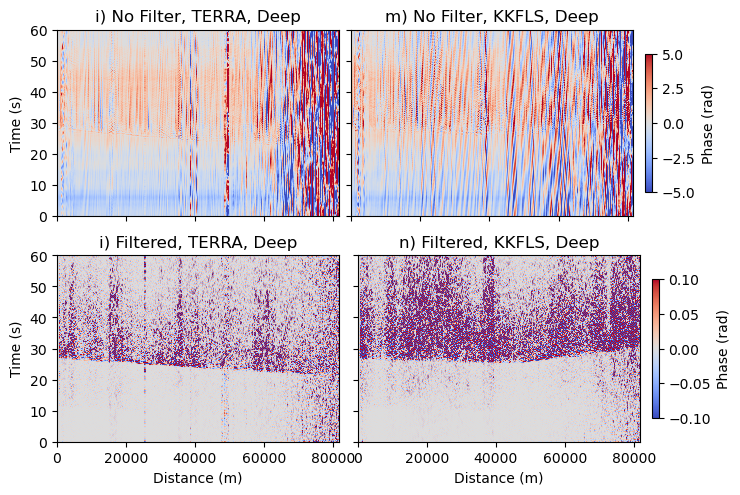

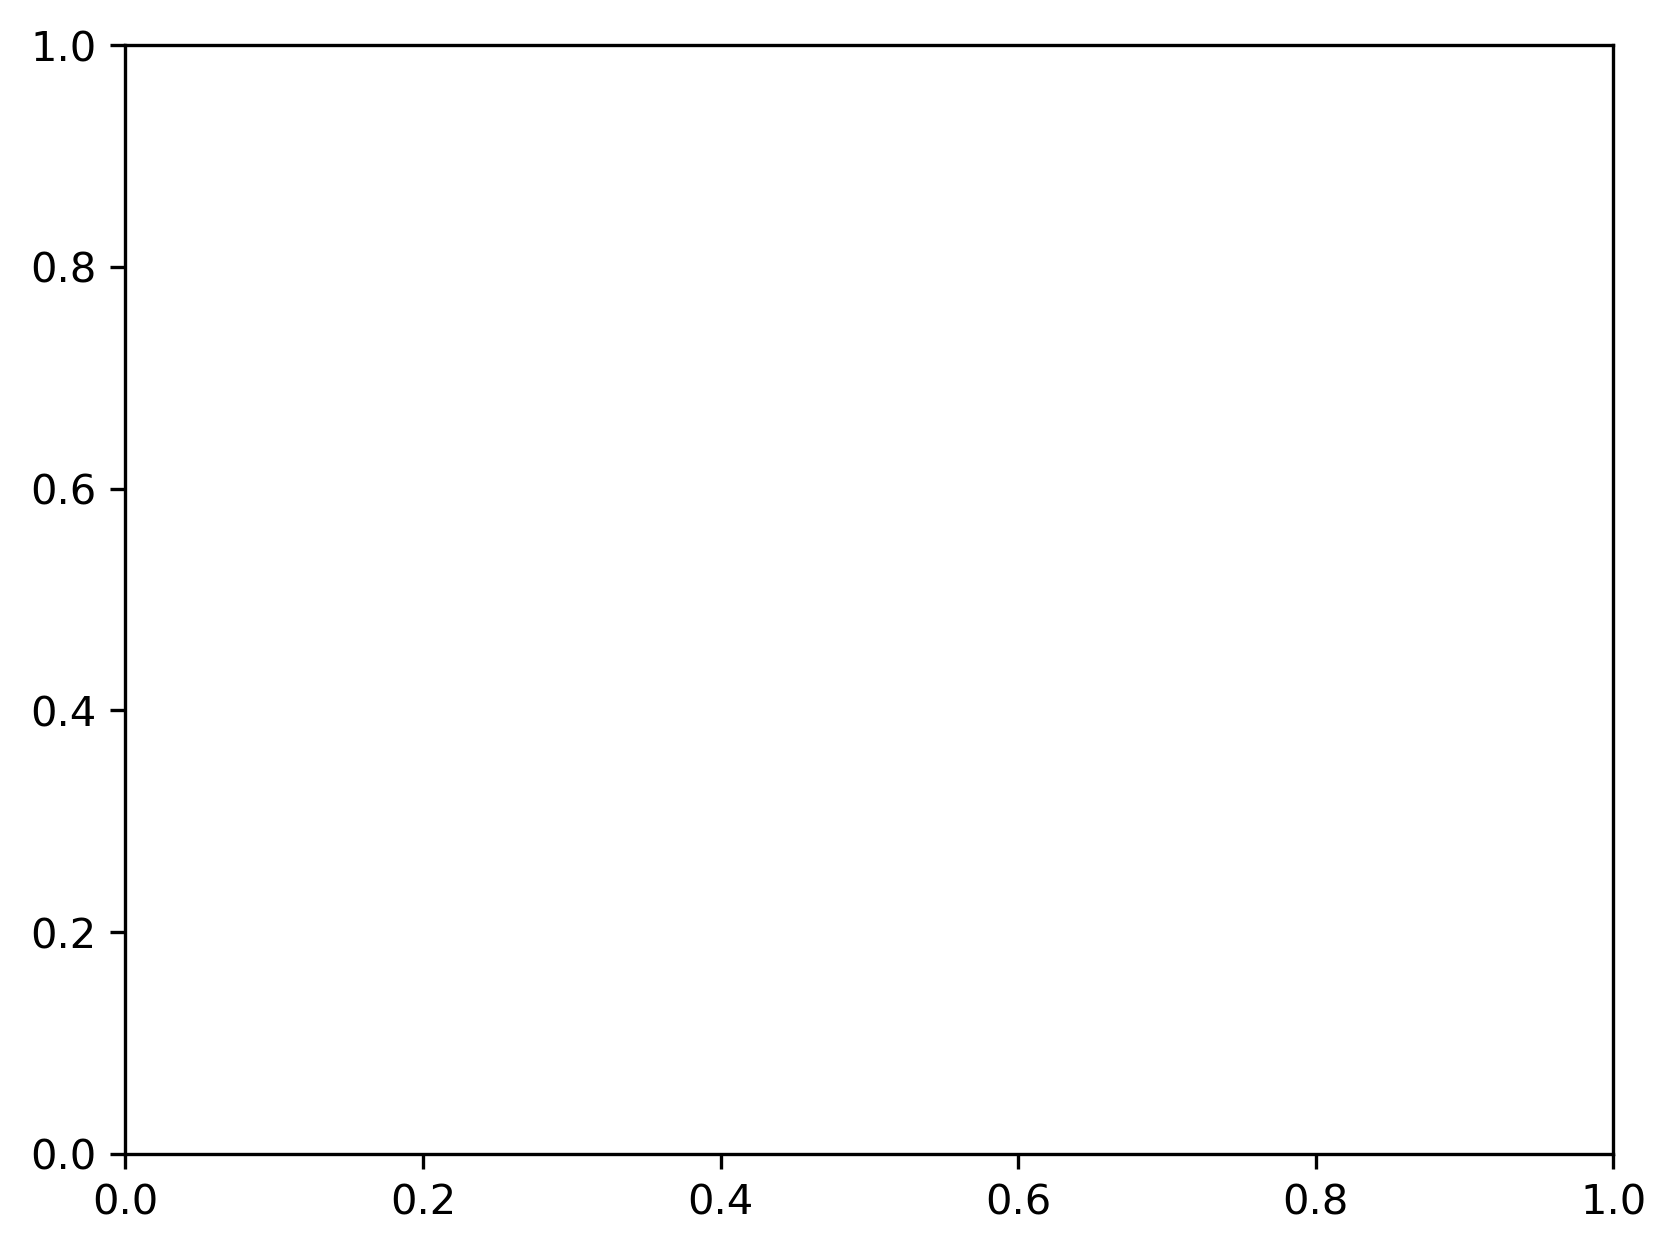

In [88]:
# Plot deep event DAS records

fig3= plt.figure()
plt.subplots(dpi=300)
ax1= fig3.add_axes([0.1, 0.51, 0.44, 0.44])
ax2= fig3.add_axes([0.1, 0.04, 0.44, 0.44])
ax3= fig3.add_axes([0.56, 0.50, 0.47, 0.46])
ax4= fig3.add_axes([0.57, 0.03, 0.47, 0.46])


# Plot DAS
vm = 5
c=ax1.imshow(dasTERRA,aspect=900,cmap='coolwarm',
             vmin=-vm,vmax=vm,extent=[xTERRA[0],xTERRA[-1],tTERRA[-1],tTERRA[0]])
ax1.set_ylabel('Time (s)')
ax1.set_xticklabels([])
ax1.set_ylim([0,60])
ax1.set_title('i) No Filter, TERRA, Deep')


# Bandpass data on DAS - stricter filter band.
vm = 0.1
bb,ab = butter(2,[2.0,12.0],'bandpass',fs=1/dtTERRA)
data_bp = filtfilt(bb,ab,dasTERRA,axis=0)

c=ax2.imshow(data_bp,aspect=900,cmap='coolwarm',
             vmin=-vm,vmax=vm,extent=[xTERRA[0],xTERRA[-1],tTERRA[-1],tTERRA[0]])
ax2.set_xlabel('Distance (m)')
ax2.set_ylabel('Time (s)')
ax2.set_ylim([0,60])
ax2.set_title('i) Filtered, TERRA, Deep')

# Plot KKFLS
vm = 5
c=ax3.imshow(dasKKFLS,aspect=900,cmap='coolwarm',
             vmin=-vm,vmax=vm,extent=[xKKFLS[0],xKKFLS[-1],tKKFLS[-1],tKKFLS[0]])
cbar=plt.colorbar(c,fraction=0.023, pad=0.04)
cbar.set_label('Phase (rad)')
ax3.set_xticklabels([])
ax3.set_yticklabels([])
ax3.set_ylim([0,60])
ax3.set_title('m) No Filter, KKFLS, Deep')


# Bandpass data on DAS - stricter filter band.
vm = 0.1
bb,ab = butter(2,[2.0,12.0],'bandpass',fs=1/dtKKFLS)
data_bp = filtfilt(bb,ab,dasKKFLS,axis=0)

c=ax4.imshow(data_bp,aspect=900,cmap='coolwarm',
             vmin=-vm,vmax=vm,extent=[xKKFLS[0],xKKFLS[-1],tKKFLS[-1],tKKFLS[0]])
cbar=plt.colorbar(c,fraction=0.023, pad=0.04)
cbar.set_label('Phase (rad)')
ax4.set_xlabel('Distance (m)')
#ax2.set_ylabel('Time (s)')
ax4.set_yticklabels([])
ax4.set_ylim([0,60])
ax4.set_title('n) Filtered, KKFLS, Deep')
plt.show()


fig3.savefig('Figures_data/DAS_deep.png',dpi=300,bbox_inches='tight')

In [89]:
# Shallow event on DAS - load DAS files

file = '/Users/golos/Research/Alaska/DAS/Data/2023.261/TERRA.h5'
dataTERRA = h5py.File(file)
attrsTERRA=dict(dataTERRA['Acquisition'].attrs)
dasTERRA = np.array(dataTERRA['Acquisition/Raw[0]/RawData'])
timeTERRA = np.array(dataTERRA['Acquisition/Raw[0]/RawDataTime'])
dataTERRA.close()
dtTERRA = 1/attrsTERRA['MaximumFrequency']/2
dxTERRA = attrsTERRA['SpatialSamplingInterval']
ntTERRA,nxTERRA = dasTERRA.shape

xTERRA = np.linspace(0,nxTERRA*dxTERRA,nxTERRA)
tTERRA = np.linspace(0,ntTERRA*dtTERRA,ntTERRA)



file = '/Users/golos/Research/Alaska/DAS/Data/2023.261/KKFLS.h5'
dataKKFLS = h5py.File(file)
attrsKKFLS=dict(dataKKFLS['Acquisition'].attrs)
dasKKFLS = np.array(dataKKFLS['Acquisition/Raw[0]/RawData'])
timeKKFLS = np.array(dataKKFLS['Acquisition/Raw[0]/RawDataTime'])
dataKKFLS.close()
dtKKFLS = 1/attrsKKFLS['MaximumFrequency']/2
dxKKFLS = attrsKKFLS['SpatialSamplingInterval']
ntKKFLS,nxKKFLS = dasKKFLS.shape

xKKFLS = np.linspace(0,nxKKFLS*dxKKFLS,nxKKFLS)
tKKFLS = np.linspace(0,ntKKFLS*dtKKFLS,ntKKFLS)



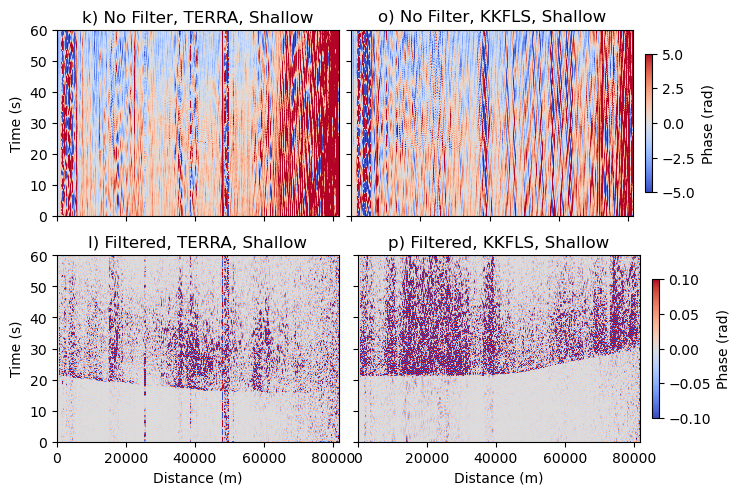

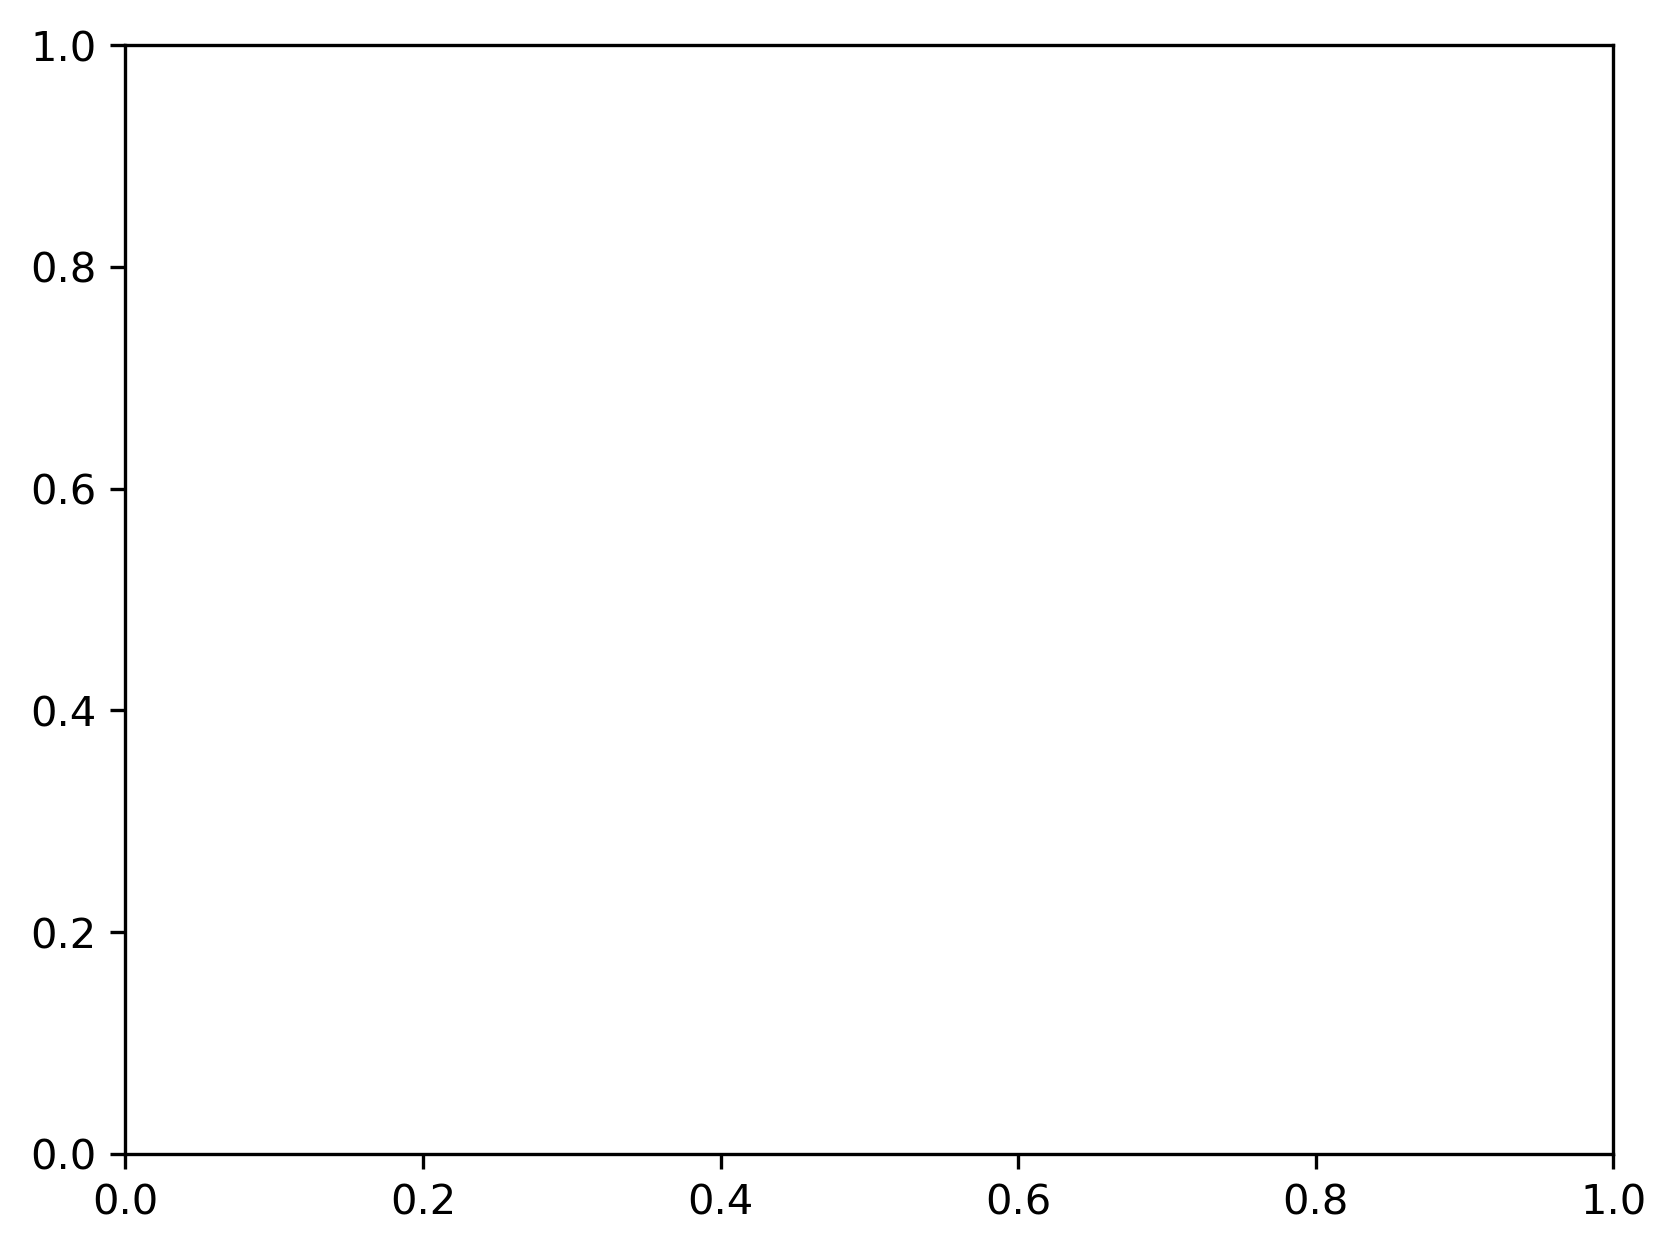

In [90]:
# Plot shallow event DAS records

fig4= plt.figure()
plt.subplots(dpi=300)
ax1= fig4.add_axes([0.1, 0.51, 0.44, 0.44])
ax2= fig4.add_axes([0.1, 0.04, 0.44, 0.44])
ax3= fig4.add_axes([0.56, 0.50, 0.47, 0.46])
ax4= fig4.add_axes([0.57, 0.03, 0.47, 0.46])


# Plot DAS
vm = 5
c=ax1.imshow(dasTERRA,aspect=900,cmap='coolwarm',
             vmin=-vm,vmax=vm,extent=[xTERRA[0],xTERRA[-1],tTERRA[-1],tTERRA[0]])
ax1.set_ylabel('Time (s)')
ax1.set_xticklabels([])
ax1.set_ylim([0,60])
ax1.set_title('k) No Filter, TERRA, Shallow')


# Bandpass data on DAS - stricter filter band.
vm = 0.1
bb,ab = butter(2,[2.0,12.0],'bandpass',fs=1/dtTERRA)
data_bp = filtfilt(bb,ab,dasTERRA,axis=0)

c=ax2.imshow(data_bp,aspect=900,cmap='coolwarm',
             vmin=-vm,vmax=vm,extent=[xTERRA[0],xTERRA[-1],tTERRA[-1],tTERRA[0]])
ax2.set_xlabel('Distance (m)')
ax2.set_ylabel('Time (s)')
#ax2.set_xlim([0,100])
ax2.set_ylim([0,60])
ax2.set_title('l) Filtered, TERRA, Shallow')


# Plot KKFLS
vm = 5
c=ax3.imshow(dasKKFLS,aspect=900,cmap='coolwarm',
             vmin=-vm,vmax=vm,extent=[xKKFLS[0],xKKFLS[-1],tKKFLS[-1],tKKFLS[0]])
cbar=plt.colorbar(c,fraction=0.023, pad=0.04)
cbar.set_label('Phase (rad)')
ax3.set_xticklabels([])
ax3.set_yticklabels([])
ax3.set_ylim([0,60])
ax3.set_title('o) No Filter, KKFLS, Shallow')


# Bandpass data on DAS - stricter filter band.
vm = 0.1
bb,ab = butter(2,[2.0,12.0],'bandpass',fs=1/dtKKFLS)
data_bp = filtfilt(bb,ab,dasKKFLS,axis=0)

c=ax4.imshow(data_bp,aspect=900,cmap='coolwarm',
             vmin=-vm,vmax=vm,extent=[xKKFLS[0],xKKFLS[-1],tKKFLS[-1],tKKFLS[0]])
cbar=plt.colorbar(c,fraction=0.023, pad=0.04)
cbar.set_label('Phase (rad)')
ax4.set_xlabel('Distance (m)')
ax4.set_yticklabels([])
ax4.set_ylim([0,60])
ax4.set_title('p) Filtered, KKFLS, Shallow')
plt.show()


fig4.savefig('Figures_data/DAS_shallow.png',dpi=300,bbox_inches='tight')